# Portfolio Risk Simulation Mini-Project

## Overview

##### In this project, we will begin looking at portfolios of stocks, and perform an array of analyses using historical data, including calculations of returns, volatility, and also Monte Carlo Simulations using both simple returns and log returns. We also began looking at plotting overall risk vs return graphs for different portfolio arrangements, as well as later plotting this with the efficient frontier curve. Please note that as I am still in the early stages of learning, Chat GPT helped me a lot with the code and mathematics for this project, and not all of the work in this project is mine. 

## Code and Analysis

##### Importing required modules and getting data from Yahoo Finance from 2023 for Apple, Microsoft and Google stocks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tickers = ['AAPL', 'MSFT', 'GOOG']
start_date = '2023-01-01'
end_date = '2023-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']
data.head()

C:\Users\prana\AppData\Local\Temp\ipykernel_2988\3673259898.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOG,MSFT
Date,,,
2023-01-03,123.330643,89.090332,234.423569
2023-01-04,124.602715,88.107063,224.169113
2023-01-05,123.281349,86.180244,217.525284
2023-01-06,127.817360,87.560806,220.088882
2023-01-09,128.339981,88.196449,222.231750


##### Getting returns DataFrame

In [3]:
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,GOOG,MSFT
Date,,,
2023-01-04,0.010314,-0.011037,-0.043743
2023-01-05,-0.010605,-0.021869,-0.029638
2023-01-06,0.036794,0.016019,0.011785
2023-01-09,0.004089,0.007259,0.009736
2023-01-10,0.004456,0.004955,0.007617


##### Weights put in each stock, and getting overall portfolio returns series based on chosen weights

In [4]:
weights = np.array([0.3, 0.35, 0.35])

In [5]:
portfolio_returns = returns.dot(weights)
portfolio_returns.head()

Date
2023-01-04   -0.016079
2023-01-05   -0.021209
2023-01-06    0.020770
2023-01-09    0.007175
2023-01-10    0.005737
dtype: float64

##### First look at Covariance - getting covariance matrix of returns and calculating volatility of portfolio from this (squareroot of overall variance)

In [6]:
cov_matrix = returns.cov()
portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_vol = np.sqrt(portfolio_var)

print("Portfolio Variance:", portfolio_var)
print("Portfolio Volatility (Std Dev):", portfolio_vol)

Portfolio Variance: 0.00017937858118789328
Portfolio Volatility (Std Dev): 0.013393228930616145


##### Running Monte Carlo Simulation using simple returns (252 trading days in a year)

In [7]:
num_days = 252
num_simulations = 10000

simulated_portfolios = np.random.normal(
    loc=np.mean(portfolio_returns),
    scale=np.std(portfolio_returns),
    size=(num_days, num_simulations))

cumulative_returns = (1 + simulated_portfolios).cumprod(axis=0)

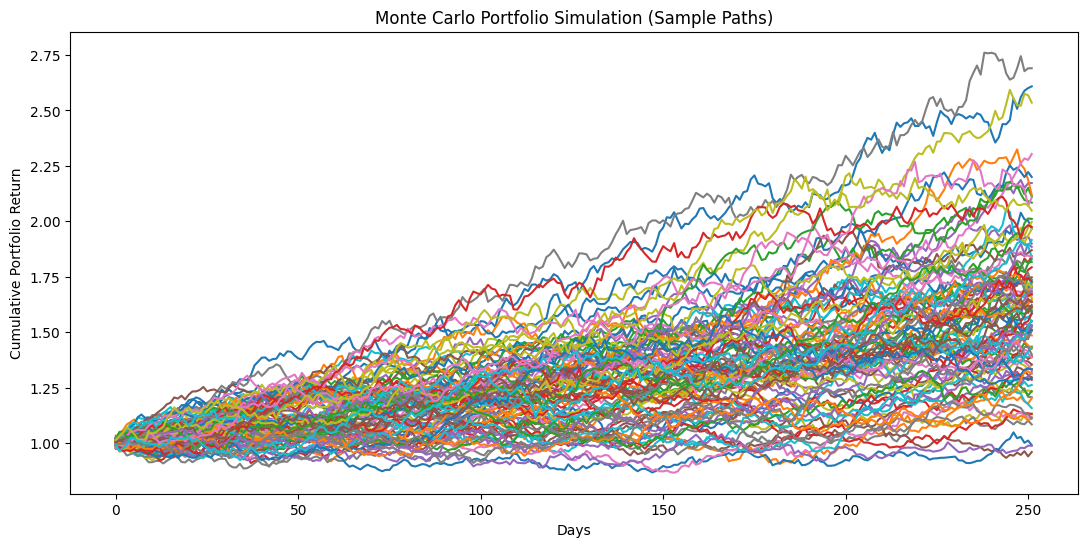

In [8]:
plt.figure(figsize=(13,6))
plt.plot(cumulative_returns[:, :100])
plt.title("Monte Carlo Portfolio Simulation (Sample Paths)")
plt.xlabel("Days")
plt.ylabel("Cumulative Portfolio Return")
plt.savefig("plots/montecarlo_port_sim_simple.png")
plt.show()

In [9]:
final_returns = cumulative_returns[-1, :]
print("Expected Portfolio Growth:", np.mean(final_returns))
print("Portfolio Risk (Std of Final Returns):", np.std(final_returns))

Expected Portfolio Growth: 1.6306991623992733
Portfolio Risk (Std of Final Returns): 0.34688070753246314


##### ^^ Overall, looks like tech companies did quite well in 2023, since an expected growth of 63% is really high. Portfolio risk is calculated from standard deviation of final returns values, and would be decreased by investing in stocks that are less highly correlated (this would cause lower covariance values and so on.) Below is a quick sanity check... still looks good...

In [10]:
print("Mean daily portfolio return:", np.mean(portfolio_returns))
print("Expected 1-year growth (approx):", (1 + np.mean(portfolio_returns))**252)

Mean daily portfolio return: 0.0019411792870229802
Expected 1-year growth (approx): 1.6302004839881017


##### Monte Carlo Simulation with log returns

In [11]:
log_returns = np.log(1 + portfolio_returns)

simulated_log = np.random.normal(
    loc=np.mean(log_returns),
    scale=np.std(log_returns),
    size=(num_days, num_simulations)
)
log_returns.head(10)

Date
2023-01-04   -0.016209
2023-01-05   -0.021437
2023-01-06    0.020557
2023-01-09    0.007150
2023-01-10    0.005721
2023-01-11    0.028356
2023-01-12    0.002557
2023-01-13    0.007454
2023-01-17    0.001850
2023-01-18   -0.009713
dtype: float64

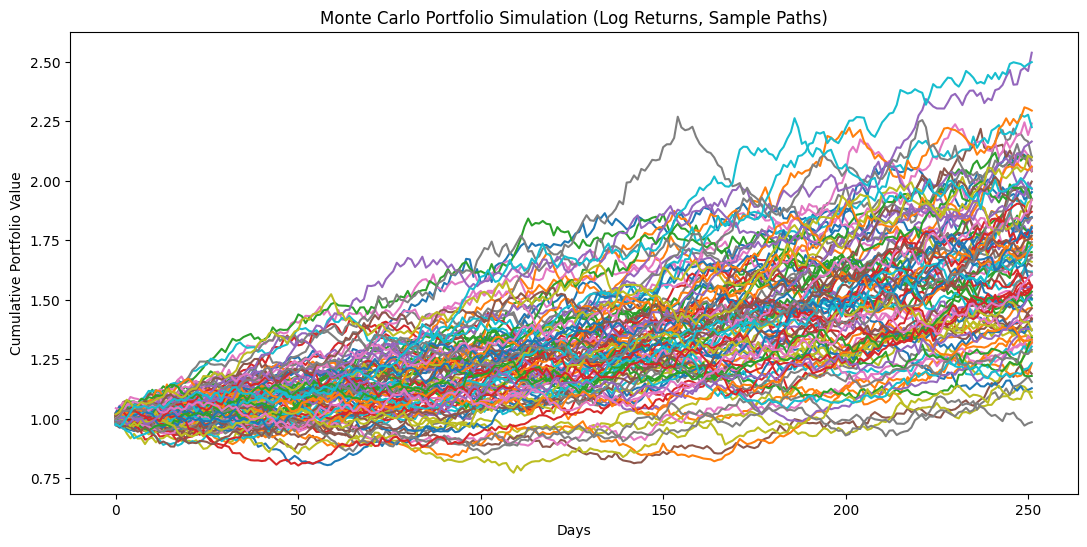

In [12]:
cumulative_log = np.exp(simulated_log.cumsum(axis=0))

plt.figure(figsize=(13,6))
plt.plot(cumulative_log[:, :100])  # first 100 paths
plt.title("Monte Carlo Portfolio Simulation (Log Returns, Sample Paths)")
plt.xlabel("Days")
plt.ylabel("Cumulative Portfolio Value")
plt.savefig("plots/montecarlo_port_sim_logreturn.png")
plt.show()

In [14]:
final_log_returns = cumulative_log[-1, :]
print("Expected Portfolio Growth (Log Returns):", np.mean(final_log_returns))
print("Portfolio Risk (Std of Final Returns, Log Returns):", np.std(final_log_returns))

Expected Portfolio Growth (Log Returns): 1.632925001439281
Portfolio Risk (Std of Final Returns, Log Returns): 0.3511809200950089


##### Overall, results are similar to simple returns when using log returns, with similar expected growth (mean of final values), and risk (standard deviation of final values). Below is a distribution of portfolio values of all the simulations after the 1 year, it shows a mean of around 1.6 too, which adds up.

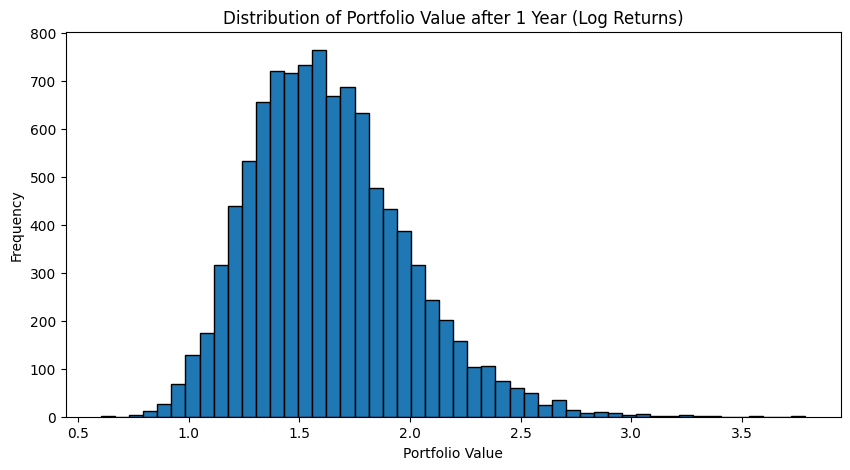

In [15]:
plt.figure(figsize=(10,5))
plt.hist(final_log_returns, bins=50, edgecolor='black')
plt.title("Distribution of Portfolio Value after 1 Year (Log Returns)")
plt.xlabel("Portfolio Value")
plt.ylabel("Frequency")
plt.savefig("plots/logreturns_portval_dist.png")
plt.show()

##### Below is calculation of VaR (Value at Risk) and  CVaR (Conditional Value at Risk). VaR is the top of the bottom 5 percent of final returns (95th percentile of final values), while CVaR is the mean of the final portfolio returns in the bottom 5 percentiles.

In [16]:
VaR_95 = np.percentile(final_log_returns, 5)
CVaR_95 = final_log_returns[final_log_returns <= VaR_95].mean()
print("95% Value at Risk (VaR):", VaR_95)
print("95% Conditional Value at Risk (CVaR):", CVaR_95)

95% Value at Risk (VaR): 1.1300321708922025
95% Conditional Value at Risk (CVaR): 1.0355423432117343


##### Portfolio Risk vs Return for 100 different portfolios with random weights. The Sharpe ratio for each portfolio is also included, it is the ratio of returns/risk for each portfolio. It appears to be highest to the left side.

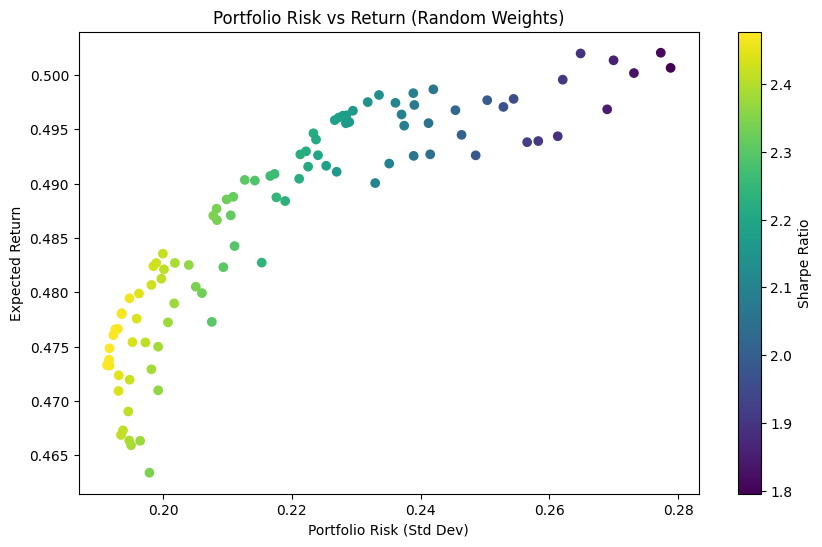

In [17]:
num_portfolios = 100
all_weights = np.random.dirichlet(np.ones(len(weights)), size=num_portfolios)
portfolio_returns_list = []
portfolio_risks_list = []

for w in all_weights:
    port_ret = np.sum(returns.mean() * w) * num_days
    port_vol = np.sqrt(np.dot(w.T, np.dot(returns.cov() * num_days, w)))
    portfolio_returns_list.append(port_ret)
    portfolio_risks_list.append(port_vol)

plt.figure(figsize=(10,6))
plt.scatter(portfolio_risks_list, portfolio_returns_list, c=np.array(portfolio_returns_list)/np.array(portfolio_risks_list), cmap='viridis')
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Portfolio Risk (Std Dev)")
plt.ylabel("Expected Return")
plt.title("Portfolio Risk vs Return (Random Weights)")
plt.savefig("plots/port_risk_vs_return_randweights.png")
plt.show()

##### Below is a graph of risk vs returns for random portfolios, but also with a plot of the efficient frontier curve, which for each given return, finds the portfolio weights with the least possible value of risk, and this least possible value of risk is plotted for each given return value. If portfolios are closer to this curve, they are more efficient, and vice versa.

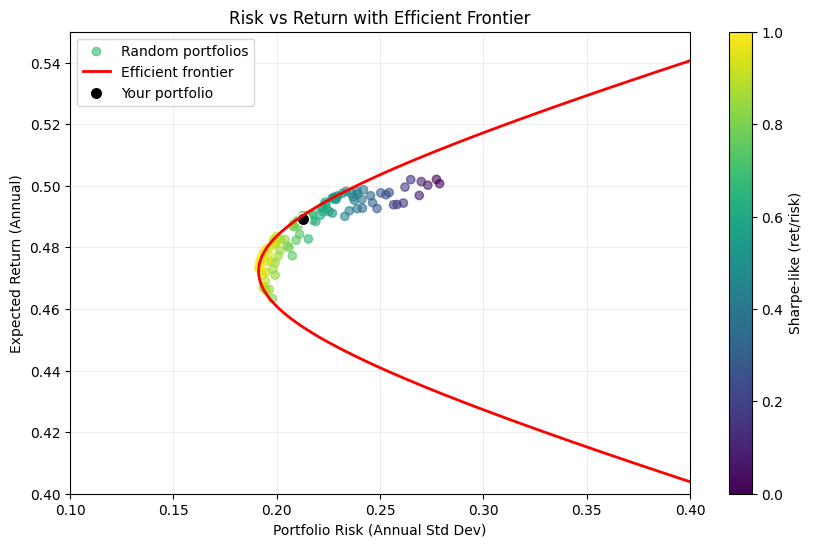

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# returns : DataFrame of daily returns
# weights : current weight vector (e.g., np.array([0.1,0.2,0.7]))
# portfolio_returns_list, portfolio_risks_list from earlier block

# Annualize returns and covariances
trading_days = num_days  # you set num_days = 252 earlier
mu_daily = returns.mean().values            # daily mean returns vector
mu_annual = mu_daily * trading_days         # annualized expected returns
cov_daily = returns.cov().values
cov_annual = cov_daily * trading_days       # annualized covariance matrix

# Prepare inverse and scalars for closed-form solution
inv_cov = np.linalg.inv(cov_annual)
ones = np.ones(len(mu_annual))

A = ones.T @ inv_cov @ ones
B = ones.T @ inv_cov @ mu_annual
C = mu_annual.T @ inv_cov @ mu_annual
D = A * C - B**2

# Range of target returns: min→max of feasible expected returns
target_returns = np.linspace(mu_annual.min()*0.8, mu_annual.max()*1.2, 200)

frontier_risks = []
frontier_rets = []

for R in target_returns:
    # weights that minimize variance for target return R:
    # w* = inv_cov @ ( (C - B*R)/D * 1 + (A*R - B)/D * mu )
    term1 = (C - B * R) / D
    term2 = (A * R - B) / D
    w_star = inv_cov @ (term1 * ones + term2 * mu_annual)
    # compute portfolio risk and return
    port_var = w_star.T @ cov_annual @ w_star
    port_sd = np.sqrt(port_var)
    frontier_risks.append(port_sd)
    frontier_rets.append(R)

# Plot: random portfolios scatter (from earlier) + efficient frontier
plt.figure(figsize=(10,6))
plt.scatter(portfolio_risks_list, portfolio_returns_list,
            c=np.array(portfolio_returns_list)/np.array(portfolio_risks_list),
            cmap='viridis', alpha=0.6, label='Random portfolios')

# efficient frontier curve
plt.plot(frontier_risks, frontier_rets, 'r-', linewidth=2, label='Efficient frontier')

# mark your chosen portfolio
current_annual_ret = np.sum(mu_daily * weights) * trading_days
current_annual_sd = np.sqrt(weights.T @ (cov_daily * trading_days) @ weights)
plt.scatter([current_annual_sd], [current_annual_ret], color='black', s=80, label='Your portfolio', edgecolor='white')

plt.xlabel("Portfolio Risk (Annual Std Dev)")
plt.ylabel("Expected Return (Annual)")
plt.title("Risk vs Return with Efficient Frontier")
plt.colorbar(label='Sharpe-like (ret/risk)')
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(0.1, 0.4)   # zoom risk axis (x-axis)
plt.ylim(0.4, 0.55)  # zoom return axis (y-axis)

# save and show
import os
os.makedirs("plots", exist_ok=True)   # adjust path if needed; you used ../plots earlier
plt.savefig("plots/efficient_frontier.png", dpi=300, bbox_inches='tight')
plt.show()


##### Below is a quick analysis of the differences between simple and log returns. Overall the two methods give the same final cumulative factor.

In [30]:
import math

r = [0.10, -0.20, 0.05]    # simple daily returns

# Simple-return compounding
simple_cum = 1
for x in r:
    simple_cum *= (1 + x)
print("Simple compounded factor:", simple_cum)
print("Simple compounded %:", (simple_cum - 1) * 100)

# Log-returns route
log_vals = [math.log(1 + x) for x in r]
sum_log = sum(log_vals)
exp_sum = math.exp(sum_log)
print("Sum of log-returns:", sum_log)
print("Exp of sum (cumulative factor):", exp_sum)
print("Equivalence check (should be True):", abs(simple_cum - exp_sum) < 1e-12)

Simple compounded factor: 0.9240000000000002
Simple compounded %: -7.5999999999999845
Sum of log-returns: -0.07904320734045273
Exp of sum (cumulative factor): 0.9240000000000002
Equivalence check (should be True): True


##### Finally, a graph of simulated final precises using log-returns, along with the lognormal probability distribution function it should approximate. The means are similar, showing that a lognormal distribution is an accurate way to model such data. 

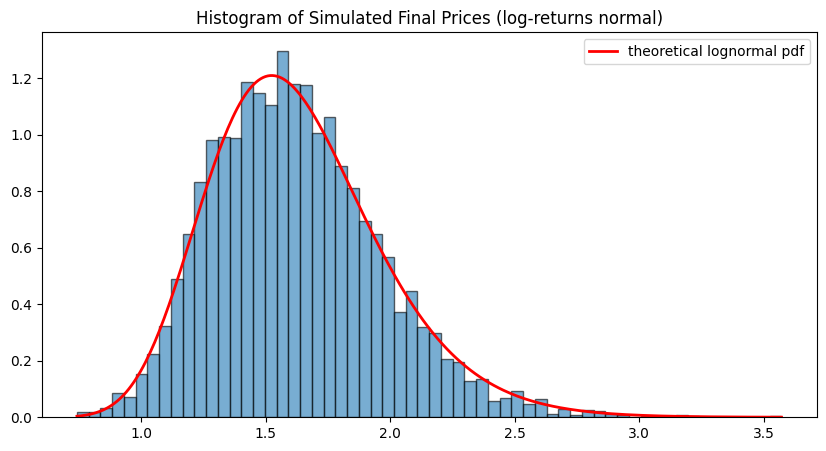

Sample mean: 1.6218269522062452
Theoretical mean: 1.6301712425871835


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, exp
from scipy.stats import lognorm  

# params
S0 = 1.0
T = 252
mu = np.mean(np.log(1 + portfolio_returns))  # or pick a value, e.g. 0.0008
sigma = np.std(np.log(1 + portfolio_returns))  # daily log-vol
n_sims = 5000

# simulate matrix of daily log-returns (iid normal)
log_rets = np.random.normal(loc=mu, scale=sigma, size=(T, n_sims))

# cumulative log-returns and prices
cum_log = log_rets.cumsum(axis=0)       # shape (T, sims)
price_paths = S0 * np.exp(cum_log)      # lognormal price paths

final_prices = price_paths[-1, :]

# histogram of final prices
plt.figure(figsize=(10,5))
plt.hist(final_prices, bins=60, density=True, edgecolor='k', alpha=0.6)
plt.title("Histogram of Simulated Final Prices (log-returns normal)")

# overlay theoretical lognormal pdf for ln S_T ~ N(ln S0 + T*mu, T*sigma^2)
mu_T = np.log(S0) + T*mu
sigma_T = np.sqrt(T) * sigma
# scipy parameterization: lognorm(s=sigma_T, scale=exp(mu_T))
x = np.linspace(final_prices.min(), final_prices.max(), 300)
pdf = lognorm.pdf(x, s=sigma_T, scale=np.exp(mu_T))
plt.plot(x, pdf, 'r-', lw=2, label="theoretical lognormal pdf")
plt.legend()
plt.show()

# compare sample mean to theoretical mean
sample_mean = final_prices.mean()
theoretical_mean = S0 * np.exp(T*mu + 0.5 * T * sigma**2)
print("Sample mean:", sample_mean)
print("Theoretical mean:", theoretical_mean)

